In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly as plty
import plotly.express as px
import math
import geoip2.database
from user_agents import parse
import os

In [ ]:
# Load df processed after first EDA
df = pd.read_csv('../data/processed_data/cybersecurity_attacks_firstEDA.csv')

# Load df before first EDA - to easily fill in na to 0 for certain columns
df0 = pd.read_csv("../data/raw/int/cybersecurity_attacks.csv")

In [4]:
df

,Timestamp,Source IP Address,Destination IP Address,Source Port,Destination Port,Protocol,Packet Length,Packet Type,Traffic Type,Malware Indicators,...,Attack Signature,Action Taken,Severity Level,Device Information,Network Segment,Geo-location Data,Proxy Information,Firewall Logs,IDS/IPS Alerts,Log Source
0,2023-05-30 06:33:58,103.216.15.12,84.9.164.252,31225,17616,ICMP,503,Data,HTTP,IoC Detected,...,Known Pattern B,Logged,Low,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment A,"Jamshedpur, Sikkim",150.9.97.135,Log Data,no Alert Data,Server
1,2020-08-26 07:08:30,78.199.217.198,66.191.137.154,17245,48166,ICMP,1174,Data,HTTP,IoC Detected,...,Known Pattern A,Blocked,Low,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment B,"Bilaspur, Nagaland",NaN,Log Data,no Alert Data,Firewall
2,2022-11-13 08:23:25,63.79.210.48,198.219.82.17,16811,53600,UDP,306,Control,HTTP,IoC Detected,...,Known Pattern B,Ignored,Low,Mozilla/5.0 (compatible; MSIE 9.0; Windows NT ...,Segment C,"Bokaro, Rajasthan",114.133.48.179,Log Data,Alert Data,Firewall
3,2023-07-02 10:38:46,163.42.196.10,101.228.192.255,20018,32534,UDP,385,Data,HTTP,no IoC Detected,...,Known Pattern B,Blocked,Medium,Mozilla/5.0 (Macintosh; PPC Mac OS X 10_11_5; ...,Segment B,"Jaunpur, Rajasthan",NaN,no Log Data,Alert Data,Firewall
4,2023-07-16 13:11:07,71.166.185.76,189.243.174.238,6131,26646,TCP,1462,Data,DNS,no IoC Detected,...,Known Pattern B,Blocked,Low,Mozilla/5.0 (compatible; MSIE 5.0; Windows NT ...,Segment C,"Anantapur, Tripura",149.6.110.119,no Log Data,Alert Data,Firewall
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,2023-05-26 14:08:42,26.36.109.26,121.100.75.240,31005,6764,UDP,1428,Control,HTTP,IoC Detected,...,Known Pattern A,Logged,Medium,Mozilla/5.0 (iPad; CPU iPad OS 14_2_1 like Mac...,Segment A,"Nashik, Manipur",NaN,Log Data,Alert Data,Firewall
39996,2023-03-27 00:38:27,17.21.163.81,196.108.134.78,2553,28091,UDP,1184,Control,HTTP,IoC Detected,...,Known Pattern A,Logged,High,Mozilla/5.0 (Windows; U; Windows 98; Win 9x 4....,Segment C,"Vadodara, Mizoram",60.51.30.46,Log Data,no Alert Data,Firewall
39997,2022-03-31 01:45:49,162.35.217.57,98.107.0.15,22505,25152,UDP,1043,Data,DNS,IoC Detected,...,Known Pattern B,Blocked,Low,Mozilla/5.0 (Windows; U; Windows NT 4.0) Apple...,Segment C,"Mahbubnagar, Himachal Pradesh",NaN,Log Data,Alert Data,Server
39998,2023-09-22 18:32:38,208.72.233.205,173.79.112.252,20013,2703,UDP,483,Data,FTP,IoC Detected,...,Known Pattern B,Ignored,Low,Mozilla/5.0 (X11; Linux i686) AppleWebKit/536....,Segment B,"Rourkela, Arunachal Pradesh",137.76.130.8,Log Data,no Alert Data,Server


### Columns with missing values that can be replaced with 1 and 0: 
1. Malware Indicators => IoC Detected or missing value => IoC Detected changed to 1, missing value changed to 0
2. Alerts/Warnings => Alert Triggered or missing value => Alert Triggered changed to 1, missing value changed to 0
3. Firewall Logs => Log Data or missing value => Log Data changed to 1, missing value changed to 0
4. IDS/IPS Alerts => Alert Data or missing value => Alert Data changed to 1, missing value changed to 0

In [ ]:
# Replace missing values with 0 for specific columns, to convert easily into binary categorical
df['Malware Indicators'] = df0['Malware Indicators']
df['Alerts/Warnings'] = df0['Alerts/Warnings']
df['IDS/IPS Alerts'] = df0['IDS/IPS Alerts']
df['Firewall Logs'] = df0['Firewall Logs']

In [6]:
df.head(10)

,Timestamp,Source IP Address,Destination IP Address,Source Port,Destination Port,Protocol,Packet Length,Packet Type,Traffic Type,Malware Indicators,...,Attack Signature,Action Taken,Severity Level,Device Information,Network Segment,Geo-location Data,Proxy Information,Firewall Logs,IDS/IPS Alerts,Log Source
0,2023-05-30 06:33:58,103.216.15.12,84.9.164.252,31225,17616,ICMP,503,Data,HTTP,IoC Detected,...,Known Pattern B,Logged,Low,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment A,"Jamshedpur, Sikkim",150.9.97.135,Log Data,NaN,Server
1,2020-08-26 07:08:30,78.199.217.198,66.191.137.154,17245,48166,ICMP,1174,Data,HTTP,IoC Detected,...,Known Pattern A,Blocked,Low,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment B,"Bilaspur, Nagaland",NaN,Log Data,NaN,Firewall
2,2022-11-13 08:23:25,63.79.210.48,198.219.82.17,16811,53600,UDP,306,Control,HTTP,IoC Detected,...,Known Pattern B,Ignored,Low,Mozilla/5.0 (compatible; MSIE 9.0; Windows NT ...,Segment C,"Bokaro, Rajasthan",114.133.48.179,Log Data,Alert Data,Firewall
3,2023-07-02 10:38:46,163.42.196.10,101.228.192.255,20018,32534,UDP,385,Data,HTTP,NaN,...,Known Pattern B,Blocked,Medium,Mozilla/5.0 (Macintosh; PPC Mac OS X 10_11_5; ...,Segment B,"Jaunpur, Rajasthan",NaN,no Log Data,Alert Data,Firewall
4,2023-07-16 13:11:07,71.166.185.76,189.243.174.238,6131,26646,TCP,1462,Data,DNS,NaN,...,Known Pattern B,Blocked,Low,Mozilla/5.0 (compatible; MSIE 5.0; Windows NT ...,Segment C,"Anantapur, Tripura",149.6.110.119,no Log Data,Alert Data,Firewall
5,2022-10-28 13:14:27,198.102.5.160,147.190.155.133,17430,52805,UDP,1423,Data,HTTP,NaN,...,Known Pattern A,Logged,Medium,Opera/8.58.(X11; Linux i686; nl-NL) Presto/2.9...,Segment C,"Aurangabad, Meghalaya",NaN,no Log Data,NaN,Server
6,2022-05-16 17:55:43,97.253.103.59,77.16.101.53,26562,17416,TCP,379,Data,DNS,NaN,...,Known Pattern B,Ignored,High,Opera/9.24.(X11; Linux i686; fa-IR) Presto/2.9...,Segment A,"Eluru, Manipur",NaN,Log Data,NaN,Server
7,2023-02-12 07:13:17,11.48.99.245,178.157.14.116,34489,20396,ICMP,1022,Data,DNS,IoC Detected,...,Known Pattern A,Logged,High,Mozilla/5.0 (Macintosh; U; PPC Mac OS X 10_7_6...,Segment A,"Phagwara, Andhra Pradesh",192.31.159.5,Log Data,Alert Data,Firewall
8,2023-06-27 11:02:56,49.32.208.167,72.202.237.9,56296,20857,TCP,1281,Control,FTP,IoC Detected,...,Known Pattern A,Blocked,High,Mozilla/5.0 (Macintosh; U; PPC Mac OS X 10_5_8...,Segment B,"Ambala, Tripura",NaN,Log Data,Alert Data,Server
9,2021-08-15 22:29:04,114.109.149.113,160.88.194.172,37918,50039,UDP,224,Data,HTTP,NaN,...,Known Pattern B,Blocked,Medium,Mozilla/5.0 (Windows; U; Windows NT 6.0) Apple...,Segment A,"Rampur, Mizoram",87.128.245.244,no Log Data,NaN,Server


In [6]:
# df['Malware Indicators'] = df['Malware Indicators'].apply(lambda x: 1 if pd.notna(x) else 0)
# use map instead of apply to affect more than one columns (dataframe)
cols_to_bin = ['Malware Indicators', 'Alerts/Warnings', 'Firewall Logs', 'IDS/IPS Alerts']
df[cols_to_bin] = df[cols_to_bin].map(lambda x: 1 if pd.notna(x) else 0)

### Timestamp - Feature Engineering & Analysis

In [4]:
# Convert object to datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

In [5]:
# Create new feature: is_weekend. In real life, some attacks might happen more during weekend then weekdays
df['is_weekend'] = df['Timestamp'].dt.dayofweek.isin([5, 6]).map({True: 1, False: 0})

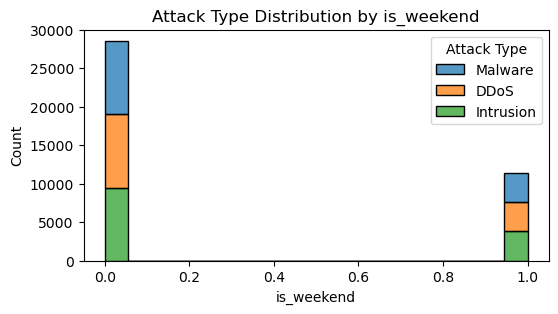

In [10]:
# Attack Type Distribution by is_weekend => fair distribution
# Conclusion: not sure if finally great feature cause it shows fair distribution ? Keep for now, maybe can help when combine with other features
plt.figure(figsize=(6,3))
sns.histplot(x= "is_weekend", hue="Attack Type", multiple = "stack", data=df)
plt.title("Attack Type Distribution by is_weekend")
plt.show()

In [7]:
# Create new feature: hours_div. In real life, attack might happen midnight to avoid detection (Malware), or during work hours to cause more disruption (DDos)?
# First bin attempt: divide to 4 parts (0-5, 6-11, 12-17, 18-23)
# fair distribution of total rows for these bins
df['hours_div'] = pd.to_datetime(df['Timestamp']).apply(
    lambda x: "0-5" if 0 <= x.hour <= 5 else
              "6-11" if 6 <= x.hour <= 11 else
              "12-17" if 12 <= x.hour <= 17 else
              "18-23" # for 18-23
)

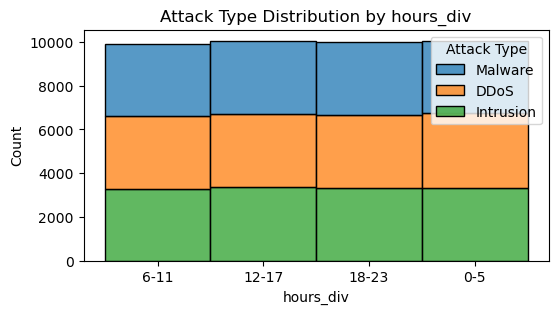

In [12]:
# Attack Type Distribution by hours_div => fair distribution
# Conclusion: not sure if finally great feature cause it shows fair distribution ? Keep for now, maybe can help when combine with other features
plt.figure(figsize=(6,3))
sns.histplot(x= "hours_div", hue="Attack Type", multiple = "stack", data=df)
plt.title("Attack Type Distribution by hours_div")
plt.show()

In [8]:
# Second bin attempt: divide to 2 parts (0-5, 6-23)
# Data distribution 25% for 0-5 and 75% for 6-23
df['hours_div'] = pd.to_datetime(df['Timestamp']).apply(
    lambda x: "0-5" if 0 <= x.hour <= 5 else
              "6-23" # for 6-23
)

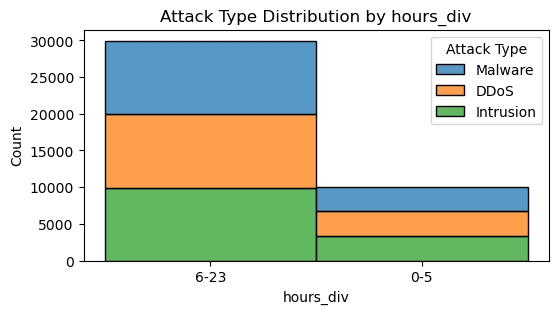

In [14]:
# Attack Type Distribution by hours_div => fair distribution
# Conclusion: not sure if finally great feature cause it shows fair distribution ? Keep for now, maybe can help when combine with other features
plt.figure(figsize=(6,3))
sns.histplot(x= "hours_div", hue="Attack Type", multiple = "stack", data=df)
plt.title("Attack Type Distribution by hours_div")
plt.show()

In [9]:
# Third bin attempt: divide to 2 parts : out of office hours (night) (6-20, 21-5)
# Data distribution 63% for 6-20 and 37% for 21-5
df['hours_div'] = pd.to_datetime(df['Timestamp']).apply(
    lambda x: "21-5" if (x.hour >= 21 or x.hour <= 5) else "6-20"
)

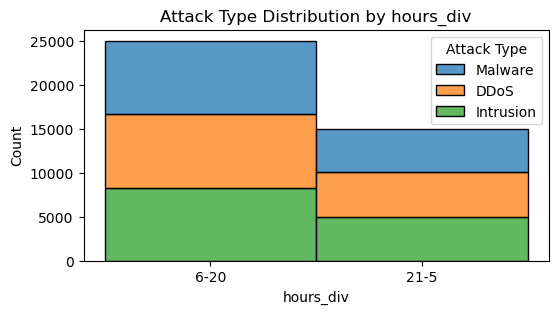

In [16]:
# Attack Type Distribution by hours_div => fair distribution
# Conclusion: not sure if finally great feature cause it shows fair distribution ? Keep for now, maybe can help when combine with other features
plt.figure(figsize=(6,3))
sns.histplot(x= "hours_div", hue="Attack Type", multiple = "stack", data=df)
plt.title("Attack Type Distribution by hours_div")
plt.show()

#### Not sure need new feature for hours divisions, and if yes, which type of bins? - to DECIDE

In [ ]:
# Delete Timestamp - no longer needed
df = df.drop(columns=['Timestamp'])

### IP Addresses - Feature Engineering & Analysis

In [ ]:
# Fill in missing values of Proxy Information as noProxy
df['Proxy Information'] = df['Proxy Information'].fillna('noProxy')

In [13]:
# Check if there are lots of repeating subnets in IP addresses
# Split all IPs to /24 subnet ==> local subnet/Single host
def splitIP24(ip):
    if pd.isna(ip):
        return pd.NA
    return ".".join(ip.split(".")[:3])

# Split all IPs to /16 subnet ==> network owner/region (ISP/backbone provider)
def splitIP16(ip):
    if pd.isna(ip):
        return pd.NA
    return ".".join(ip.split(".")[:2])

df['Source IP Address_24'] = df['Source IP Address'].apply(splitIP24)
df['Source IP Address_16'] = df['Source IP Address'].apply(splitIP16)

df['Destination IP Address_24'] = df['Destination IP Address'].apply(splitIP24)
df['Destination IP Address_16'] = df['Destination IP Address'].apply(splitIP16)

df['Proxy Information_24'] = df['Proxy Information'].apply(splitIP24)
df['Proxy Information_16'] = df['Proxy Information'].apply(splitIP16)

In [ ]:
df['Source IP Address_24'].nunique(), df['Source IP Address_16'].nunique()
# (39941, 28716)

(39941, 28716)

In [ ]:
df['Destination IP Address_24'].nunique(), df['Destination IP Address_16'].nunique()
# (39958, 28670)

(39958, 28670)

In [ ]:
df['Proxy Information_24'].nunique(), df['Proxy Information_16'].nunique()
# (20130, 16925)

(20130, 16925)

In [ ]:
# Drop these 6 columns - not interesting after checking unique counts, high cardinality
df = df.drop(columns=['Source IP Address_24', 'Source IP Address_16', 
'Destination IP Address_24', 'Destination IP Address_16', 
'Proxy Information_24', 'Proxy Information_16'])

In [15]:
# Check private range
# • 10.0.0.0 – 10.255.255.255 
# • 172.16.0.0 – 172.31.255.255 
# • 192.168.0.0 – 192.168.255.255

def isPrivateIP(ip):
    if pd.isna(ip):
        return pd.NA
    octets = ip.split(".")
    first = int(octets[0])
    second = int(octets[1])
    if first == 10:
        return True
    elif first == 172 and 16 <= second <= 31:
        return True
    elif first == 192 and second == 168:
        return True
    else:
        return False

df['isPrivate_Source'] = df['Source IP Address'].apply(isPrivateIP)
df['isPrivate_Destination'] = df['Destination IP Address'].apply(isPrivateIP)
df['isPrivate_Proxy'] = df['Proxy Information'].apply(isPrivateIP)

In [16]:
df['isPrivate_Source'].value_counts(dropna=False) # True = 181
df['isPrivate_Destination'].value_counts(dropna=False) # True = 174
df['isPrivate_Proxy'].value_counts(dropna=False) # True = 84

isPrivate_Proxy
False    20065
<NA>     19851
True        84
Name: count, dtype: int64

In [ ]:
# Less than 1% of total private IPs, not interesting to keep for ML modeling, drop
df = df.drop(columns=['isPrivate_Source', 'isPrivate_Destination', 'isPrivate_Proxy'])

In [ ]:
# Create new feature of continent and country for IP addresses
import geoip2.errors
with geoip2.database.Reader('./data/raw/ext/GeoLite2-Country_20251212/GeoLite2-Country.mmdb') as reader:
    def _lookup_ip(ip):
        # 1. Handle missing/NA values
        if not ip or pd.isna(ip):
            return {
                'ContinentName': pd.NA,
                'CountryName': pd.NA,
            }
        if ip == 'noProxy':
            return {
                'ContinentName': 'noProxy',
                'CountryName': 'noProxy',
            }
        
        # 2. Perform external lookup
        try:
            response = reader.country(ip)
            
            # 3. RETURN A DICTIONARY of all desired features
            return {
                'ContinentName': response.continent.name,
                'CountryName': response.country.name,
            }
        
        except geoip2.errors.AddressNotFoundError:
            # 4. Return NA dictionary for not found IPs
            return {
                'ContinentName': pd.NA,
                'CountryName': pd.NA,
            }
        except Exception:
            # 5. Return NA dictionary for other errors
            return {
                'ContinentName': pd.NA,
                'CountryName': pd.NA,
            }

    # --- Applying the Function ---
    geo_results_sourceIP = df['Source IP Address'].apply(_lookup_ip)
    geo_results_destIP = df['Destination IP Address'].apply(_lookup_ip)
    geo_results_proxyIP = df['Proxy Information'].apply(_lookup_ip)

    # print('geo_results_sourceIP', geo_results_sourceIP)
    # Convert list of dictionaries to DataFrame
    geo_df_sourceIP = pd.DataFrame(geo_results_sourceIP.tolist(), index=geo_results_sourceIP.index)
    # print('geo_df_sourceIP', geo_df_sourceIP)
    geo_df_destIP = pd.DataFrame(geo_results_destIP.tolist(), index=geo_results_destIP.index)
    # print('geo_df_destIP', geo_df_destIP)

    geo_df_proxyIP = pd.DataFrame(geo_results_proxyIP.tolist(), index=geo_results_proxyIP.index)

    # test to df_test before real df
    # df_test.loc[:, ('ContinentName_Source', 'CountryName_Source')] = geo_df_sourceIP[['ContinentName', 'CountryName']]
    # Source IP
    df['ContinentName_Source'] = geo_df_sourceIP['ContinentName']
    df['CountryName_Source'] = geo_df_sourceIP['CountryName']
    # df.loc[:, ('ContinentName_Source', 'CountryName_Source')] = geo_df_sourceIP[['ContinentName', 'CountryName']]
    # print('am here')
    
    # Destination IP
    df['ContinentName_Destination'] = geo_df_destIP['ContinentName']
    df['CountryName_Destination'] = geo_df_destIP['CountryName']

    # Proxy IP
    df['ContinentName_Proxy'] = geo_df_proxyIP['ContinentName']
    df['CountryName_Proxy'] = geo_df_proxyIP['CountryName']

In [19]:
# # Missing value for continent => replace with 'Unknown'
# ContinentName_Source 357
# ContinentName_Destination 338
# ContinentName_Proxy 20017
df['ContinentName_Source'] = df['ContinentName_Source'].fillna('Unknown')
df['ContinentName_Destination'] = df['ContinentName_Destination'].fillna('Unknown')
df['ContinentName_Proxy'] = df['ContinentName_Proxy'].fillna('Unknown')

In [20]:
# Calculate total for each ContinentName_Source
# Maybe take top 3 (44%, 25%, 21%) and put others for the rest
continent_counts = df['ContinentName_Source'].value_counts()
continent_pct = (df['ContinentName_Source'].value_counts(normalize=True) * 100).round(2)

continent_summary = pd.DataFrame({
    'Count': continent_counts,
    'Percentage': continent_pct
})

continent_summary

,Count,Percentage
ContinentName_Source,,
North America,17562,43.90
Asia,10045,25.11
Europe,8472,21.18
South America,1690,4.23
Africa,1212,3.03
Oceania,661,1.65
Unknown,357,0.89
Antarctica,1,0.00


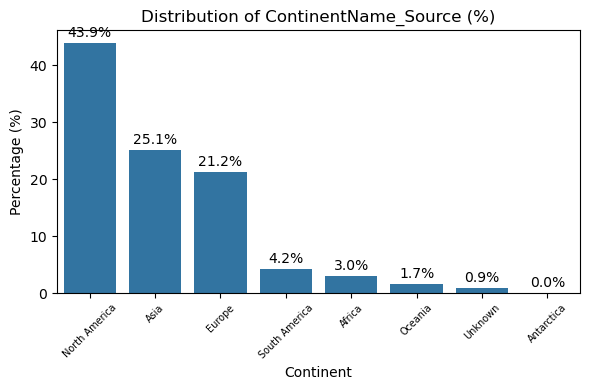

In [21]:
# Calculate percentage for each ContinentName_Source
continent_pct = df['ContinentName_Source'].value_counts(normalize=True) * 100

plt.figure(figsize=(6,4))
ax = sns.barplot(x=continent_pct.index, y=continent_pct.values)
plt.title("Distribution of ContinentName_Source (%)")
plt.ylabel("Percentage (%)")
plt.xlabel("Continent")
plt.xticks(rotation=45, fontsize=7)

# Annotate each bar with the percentage value
for i, v in enumerate(continent_pct.values):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

In [22]:
# Calculate total for each ContinentName_Destination
# Maybe take top 3 (44%, 25%, 21%) and put others for the rest
continent_counts = df['ContinentName_Destination'].value_counts()
continent_pct = (df['ContinentName_Destination'].value_counts(normalize=True) * 100).round(2)

continent_summary = pd.DataFrame({
    'Count': continent_counts,
    'Percentage': continent_pct
})

continent_summary

,Count,Percentage
ContinentName_Destination,,
North America,17538,43.84
Asia,10202,25.50
Europe,8457,21.14
South America,1655,4.14
Africa,1194,2.99
Oceania,616,1.54
Unknown,338,0.84


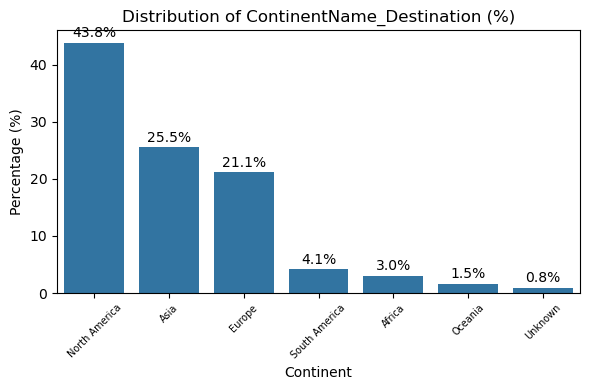

In [23]:
# Calculate percentage for each ContinentName_Destination
continent_pct = df['ContinentName_Destination'].value_counts(normalize=True) * 100

plt.figure(figsize=(6,4))
ax = sns.barplot(x=continent_pct.index, y=continent_pct.values)
plt.title("Distribution of ContinentName_Destination (%)")
plt.ylabel("Percentage (%)")
plt.xlabel("Continent")
plt.xticks(rotation=45, fontsize=7)

# Annotate each bar with the percentage value
for i, v in enumerate(continent_pct.values):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

In [24]:
# Calculate total for each ContinentName_Proxy
# Maybe take top 3 (43%, 26%, 21%) and put others for the rest
continent_counts = df['ContinentName_Proxy'].value_counts()
continent_pct = (df['ContinentName_Proxy'].value_counts(normalize=True) * 100).round(2)

continent_summary = pd.DataFrame({
    'Count': continent_counts,
    'Percentage': continent_pct
})

continent_summary

,Count,Percentage
ContinentName_Proxy,,
Unknown,20017,50.04
North America,8752,21.88
Asia,5232,13.08
Europe,4242,10.60
South America,819,2.05
Africa,609,1.52
Oceania,329,0.82


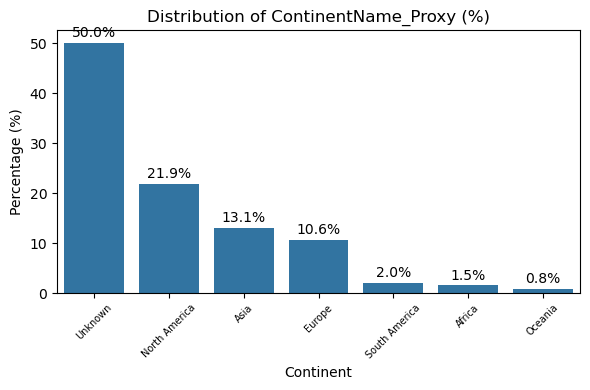

In [25]:
# Calculate percentage for each ContinentName_Proxy
continent_pct = df['ContinentName_Proxy'].value_counts(normalize=True) * 100

plt.figure(figsize=(6,4))
ax = sns.barplot(x=continent_pct.index, y=continent_pct.values)
plt.title("Distribution of ContinentName_Proxy (%)")
plt.ylabel("Percentage (%)")
plt.xlabel("Continent")
plt.xticks(rotation=45, fontsize=7)

# Annotate each bar with the percentage value
for i, v in enumerate(continent_pct.values):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

In [26]:
# Calculate percentage for each CountryName_Source
country_counts = df['CountryName_Source'].value_counts()
country_pct = (df['CountryName_Source'].value_counts(normalize=True) * 100).round(2)

country_summary = pd.DataFrame({
    'Count': country_counts,
    'Percentage': country_pct
})

country_summary

,Count,Percentage
CountryName_Source,,
United States,16356,41.26
China,3663,9.24
Japan,2190,5.52
Germany,1475,3.72
United Kingdom,1420,3.58
...,...,...
Nauru,1,0.00
Montserrat,1,0.00
Heard and McDonald Islands,1,0.00


In [27]:
# Calculate percentage for each CountryName_Destination
country_counts = df['CountryName_Destination'].value_counts()
country_pct = (df['CountryName_Destination'].value_counts(normalize=True) * 100).round(2)

country_summary = pd.DataFrame({
    'Count': country_counts,
    'Percentage': country_pct
})

country_summary

,Count,Percentage
CountryName_Destination,,
United States,16262,41.00
China,3729,9.40
Japan,2143,5.40
Germany,1423,3.59
United Kingdom,1406,3.55
...,...,...
Liechtenstein,1,0.00
Belize,1,0.00
Antigua and Barbuda,1,0.00


In [28]:
# Calculate percentage for each CountryName_Proxy
country_counts = df['CountryName_Proxy'].value_counts()
country_pct = (df['CountryName_Proxy'].value_counts(normalize=True) * 100).round(2)

country_summary = pd.DataFrame({
    'Count': country_counts,
    'Percentage': country_pct
})

country_summary

,Count,Percentage
CountryName_Proxy,,
United States,8150,40.79
China,1872,9.37
Japan,1113,5.57
United Kingdom,732,3.66
Germany,723,3.62
...,...,...
American Samoa,1,0.01
Mongolia,1,0.01
Afghanistan,1,0.01


In [29]:
df['CountryName_Source'].nunique(), df['CountryName_Destination'].nunique(), df['CountryName_Proxy'].nunique()
# (186, 179, 162)
# Conclusion: high cardinality
# Top 1 country has around 40%,  Top 2 - 9%, Top 3 - 5%, rest below 5%
# Either take top 3 country or drop all

(186, 179, 162)

In [ ]:
# Drop country_name for all IP addresses, high cardinality
df = df.drop(columns=['CountryName_Source', 'CountryName_Destination', 'CountryName_Proxy'])

In [31]:
# Fill missing values in Proxy Information as noProxy
df['Proxy Information'] = df['Proxy Information'].fillna('noProxy')

In [32]:
# Create new feature for IP addresses (Source, Destination, Proxy) by IP class
# https://www.geeksforgeeks.org/computer-networks/introduction-of-classful-ip-addressing/
# Class A = 0-127 => very large networks
# Class B = 128-191 => medium-large networks
# Class C = 192-223 => small networks
# Class D = 224-239 => multicast communication
# Class E = 240-255 => experimental and research purposes
def get_ip_class(ip):
    first_octet = int(ip.split('.')[0])
    if 0 <= first_octet <= 127:
        return 'A'
    elif 128 <= first_octet <= 191:
        return 'B'
    elif 192 <= first_octet <= 223:
        return 'C'
    elif 224 <= first_octet <= 239:
        return 'D'
    elif 240 <= first_octet <= 255:
        return 'E'
    else:
        return 'Unknown'

df['Source IP_Class'] = df['Source IP Address'].apply(get_ip_class)
df['Destination IP_Class'] = df['Destination IP Address'].apply(get_ip_class)
df['Proxy_Class'] = df['Proxy Information'].apply(lambda x: 'noProxy' if x == 'noProxy' else get_ip_class(x))

In [33]:
count = df['Source IP_Class'].value_counts()
pct = (df['Source IP_Class'].value_counts(normalize=True) * 100).round(2)

Source_IP_Class_summary = pd.DataFrame({
    'Count': count,
    'Percentage': pct
})

Source_IP_Class_summary

,Count,Percentage
Source IP_Class,,
A,22752,56.88
B,11452,28.63
C,5796,14.49


In [34]:
count = df['Destination IP_Class'].value_counts()
pct = (df['Destination IP_Class'].value_counts(normalize=True) * 100).round(2)

Destination_IP_Class_summary = pd.DataFrame({
    'Count': count,
    'Percentage': pct
})

Destination_IP_Class_summary

,Count,Percentage
Destination IP_Class,,
A,22723,56.81
B,11477,28.69
C,5800,14.50


In [35]:
count = df['Proxy_Class'].value_counts()
pct = (df['Proxy_Class'].value_counts(normalize=True) * 100).round(2)

Proxy_Class_summary = pd.DataFrame({
    'Count': count,
    'Percentage': pct
})

Proxy_Class_summary

,Count,Percentage
Proxy_Class,,
noProxy,19851,49.63
A,11491,28.73
B,5754,14.38
C,2904,7.26


In [ ]:
# Drop columns 'Source IP Address', 'Destination IP Address' and 'Proxy Information'
# as they are no longer needed
df = df.drop(columns=['Source IP Address', 'Destination IP Address', 'Proxy Information'])

In [37]:
# Analyse of Source Port
df['Destination Port'].nunique(), df['Source Port'].nunique()
# (29895, 29761)
# Can't use these features, too many distinct values

(29895, 29761)

In [38]:
# 8333 unique same source ports appear more than once of total 29761 distinct source ports, means around 30%
# High cardinality, won't use
df['Source Port'].value_counts()[df['Source Port'].value_counts() > 1]

Source Port
41341    6
31656    5
45874    5
15669    5
35304    5
        ..
22301    2
25913    2
6722     2
19207    2
25022    2
Name: count, Length: 8333, dtype: int64

In [39]:
# 8217 unique destination ports appear more than once
# of total 29895 unique destination ports, means around 27.5%
# Maybe can't use this cause when we divide the dataset in train/test, we won't have same result of frequency of destination port appearing
df['Destination Port'].value_counts()[df['Destination Port'].value_counts() > 1]

Destination Port
7508     6
34117    6
39887    5
15150    5
30804    5
        ..
60667    2
43767    2
14773    2
50174    2
20649    2
Name: count, Length: 8217, dtype: int64

In [40]:
# Create new features for ports based on port categories
# HTTPS 443, SSH 22, DNS 53, FTP 20-21
# Well-known (0–1023) → common services (HTTP, FTP, DNS, etc.) 
# User/Registered Ports (1024-49151) → used by Server, Application, Database, VPN (HTTP alternate 8080, MySQL 3306) 
# Dynamic and/or Private Ports (49152-65535) → temporary/ephemeral ports for outgoing connections, used by Clients. Rapid rotation may signal botnets. 
# Plot to see distribution of these different ports vs packet length ?
def portCategory(port):
    if pd.isna(port):
        return pd.NA
    elif 0 <= port <= 1023:
        return 'Wellknown'
    elif 1024 <= port <= 49151:
        return 'Registered'
    elif 49152 <= port <= 65535:
        return 'Dynamic'
    else:
        return 'Invalid'

df['Source Port_Cat'] = df['Source Port'].apply(portCategory)
df['Destination Port_Cat'] = df['Destination Port'].apply(portCategory)

In [ ]:
# Drop Source Port and Destination Port as no longer needed
df = df.drop(columns=['Source Port', 'Destination Port'])

In [42]:
# No anomaly detected, seems pretty fairly spread
df['Packet Length'].describe()

count    40000.000000
mean       781.452725
std        416.044192
min         64.000000
25%        420.000000
50%        782.000000
75%       1143.000000
max       1500.000000
Name: Packet Length, dtype: float64

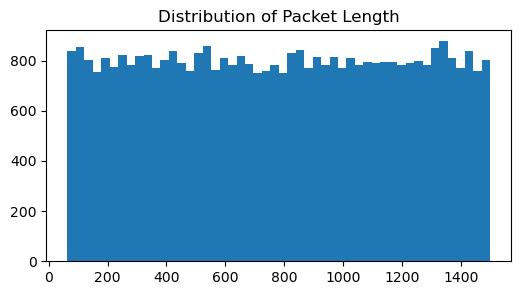

In [43]:
# Packet Length are spread almost evenly
plt.figure(figsize=(6,3))
plt.hist(df['Packet Length'], bins=50)
plt.title("Distribution of Packet Length")
plt.show()

In [44]:
# Option 1 - Create new feature for Packet Length - by octet bins ?
# Conclusion: First three bins have so small percentage => 0-64 - less than 1%, 64-128 - 5%, 128-258 - 8%
# Imbalance data, too less data especially for three bins mentioned above
df['Packet Length_Bin'] = pd.cut(
    df['Packet Length'], 
    bins=[0, 64, 128, 256, 512, 1024, 2048], # max value is 2048
    labels=['0-64', '64-128', '128-256', '256-512', '512-1024', '1024-2048']
)

ct_percentage = pd.crosstab(df['Packet Length_Bin'], df['Attack Type'], normalize='index') * 100
ct_percentage['Total %'] = ct_percentage.sum(axis=1)
ct_percentage = ct_percentage.round(2)
print(ct_percentage)
print("="*100)

ct_qty = pd.crosstab(df['Packet Length_Bin'], df['Attack Type'])
ct_qty['Total'] = ct_qty.sum(axis=1)
grand_total = ct_qty['Total'].sum()
ct_qty['% bin of Total'] = (ct_qty['Total'] / grand_total * 100).round(2)
ct_qty.loc['Total Attack'] = ct_qty.sum(axis = 0)
# ct_qty.loc['Total Attack', '% bin of Total'] = 100.00
print(ct_qty)

Attack Type         DDoS  Intrusion  Malware  Total %
Packet Length_Bin                                    
0-64               51.52      24.24    24.24    100.0
64-128             32.51      33.32    34.18    100.0
128-256            33.93      34.22    31.85    100.0
256-512            32.69      33.42    33.89    100.0
512-1024           33.53      32.69    33.78    100.0
1024-2048          34.09      33.26    32.65    100.0
Attack Type           DDoS  Intrusion  Malware    Total  % bin of Total
Packet Length_Bin                                                      
0-64                  17.0        8.0      8.0     33.0            0.08
64-128               605.0      620.0    636.0   1861.0            4.65
128-256             1192.0     1202.0   1119.0   3513.0            8.78
256-512             2335.0     2387.0   2421.0   7143.0           17.86
512-1024            4751.0     4631.0   4786.0  14168.0           35.42
1024-2048           4528.0     4417.0   4337.0  13282.0         

In [45]:
df['Packet Length'].describe()

count    40000.000000
mean       781.452725
std        416.044192
min         64.000000
25%        420.000000
50%        782.000000
75%       1143.000000
max       1500.000000
Name: Packet Length, dtype: float64

In [ ]:
# Option 2 - Create new feature for Packet Length - by quartile
# Conclusion: more fairly spread bins, may be better to use than option 1 ?
df['Packet Length_Quartile'] = pd.cut(
    df['Packet Length'], 
    bins=[63, 420, 782, 1143, 1501], # min: 64, max: 1500
    labels=['Q1: 64-420', 'Q2: 421-782', 'Q3: 783-1143', 'Q4: 1144-1500']
)

ct_percentage = pd.crosstab(df['Packet Length_Quartile'], df['Attack Type'], normalize='index') * 100
ct_percentage['Total %'] = ct_percentage.sum(axis=1)
ct_percentage = ct_percentage.round(2)
print(ct_percentage)
print("="*100)

ct_qty = pd.crosstab(df['Packet Length_Quartile'], df['Attack Type'])
ct_qty['Total'] = ct_qty.sum(axis=1)
grand_total = ct_qty['Total'].sum()
ct_qty['% bin of Total'] = (ct_qty['Total'] / grand_total * 100).round(2)
ct_qty.loc['Total Attack'] = ct_qty.sum(axis = 0)
# ct_qty.loc['Total Attack', '% bin of Total'] = 100.00
print(ct_qty)

Attack Type              DDoS  Intrusion  Malware  Total %
Packet Length_Quartile                                    
Q1: 64-420              33.30      33.94    32.76    100.0
Q2: 421-782             33.55      32.15    34.29    100.0
Q3: 783-1143            33.17      33.29    33.53    100.0
Q4: 1144-1500           34.25      33.26    32.48    100.0
Attack Type                DDoS  Intrusion  Malware    Total  % bin of Total
Packet Length_Quartile                                                      
Q1: 64-420               3331.0     3395.0   3277.0  10003.0           25.01
Q2: 421-782              3357.0     3217.0   3431.0  10005.0           25.01
Q3: 783-1143             3320.0     3332.0   3356.0  10008.0           25.02
Q4: 1144-1500            3420.0     3321.0   3243.0   9984.0           24.96
Total Attack            13428.0    13265.0  13307.0  40000.0          100.00


In [ ]:
# drop Packet Length - no longer needed
df = df.drop(columns=['Packet Length'])

In [48]:
# No anomaly detected, seems pretty fairly spread
df['Anomaly Scores'].describe()

count    40000.000000
mean        50.113473
std         28.853598
min          0.000000
25%         25.150000
50%         50.345000
75%         75.030000
max        100.000000
Name: Anomaly Scores, dtype: float64

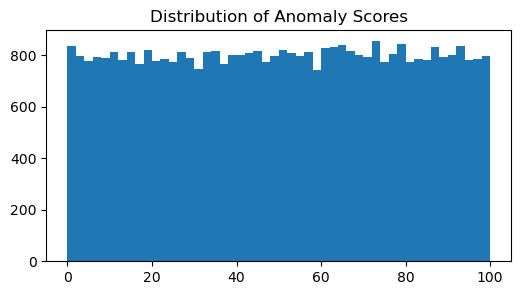

In [49]:
# Anomaly Scores are spread almost evenly
plt.figure(figsize=(6,3))
plt.hist(df['Anomaly Scores'], bins=50)
plt.title("Distribution of Anomaly Scores")
plt.show()

In [ ]:
# Create new feature for Anomaly Scores - by quartile
df['Anomaly Scores_Quartile'] = pd.cut(
    df['Anomaly Scores'],
    bins=[-1, 25, 50, 75, 101], # min is 0, max is 100
    labels=['Low (0-24)', 'Medium (25-49)', 'High (50-74)', 'Very High (75-100)']
)

ct_percentage = pd.crosstab(df['Anomaly Scores_Quartile'], df['Attack Type'], normalize='index') * 100
ct_percentage['Total %'] = ct_percentage.sum(axis=1)
ct_percentage = ct_percentage.round(2)
print(ct_percentage)
print("="*100)

ct_qty = pd.crosstab(df['Anomaly Scores_Quartile'], df['Attack Type'])
ct_qty['Total'] = ct_qty.sum(axis=1)
grand_total = ct_qty['Total'].sum()
ct_qty['% bin of Total'] = (ct_qty['Total'] / grand_total * 100).round(2)
ct_qty.loc['Total Attack'] = ct_qty.sum(axis = 0)
# ct_qty.loc['Total Attack', '% bin of Total'] = 100.00
print(ct_qty)

Attack Type               DDoS  Intrusion  Malware  Total %
Anomaly Scores_Quartile                                    
Low (0-25)               33.18      33.50    33.31    100.0
Medium (25-50)           33.91      33.08    33.01    100.0
High (50-75)             33.58      33.26    33.16    100.0
Critical (75-100)        33.60      32.80    33.59    100.0
Attack Type                 DDoS  Intrusion  Malware    Total  % bin of Total
Anomaly Scores_Quartile                                                      
Low (0-25)                3303.0     3335.0   3316.0   9954.0           24.88
Medium (25-50)            3363.0     3280.0   3273.0   9916.0           24.79
High (50-75)              3398.0     3366.0   3355.0  10119.0           25.30
Critical (75-100)         3364.0     3284.0   3363.0  10011.0           25.03
Total Attack             13428.0    13265.0  13307.0  40000.0          100.00


In [ ]:
# Drop Anomaly Scores as no longer needed
df = df.drop(columns=['Anomaly Scores'])

### Feature Engineering and Analysis for Device Information

In [52]:
# Use parse to recuperate more features from 'Device Information' which now contain non atomic information
df['Browser_family'] = df['Device Information'].apply(lambda x: parse(x).browser.family if parse(x).browser.family is not None else pd.NA)
df['Browser_major'] = df['Device Information'].apply(lambda x: parse(x).browser.version[0] if parse(x).browser.version[0] is not None else pd.NA)
df['Browser_minor'] = df['Device Information'].apply(lambda x: parse(x).browser.version[1] if parse(x).browser.version[1] is not None else pd.NA)
df['OS_family'] = df['Device Information'].apply(lambda x: parse(x).os.family if parse(x).os.family is not None else pd.NA)
df['OS_major'] = df['Device Information'].apply(
    lambda x: parse(x).os.version[0] if len(parse(x).os.version) > 0 and parse(x).os.version[0] is not None else pd.NA
)
df['OS_minor'] = df['Device Information'].apply(
    lambda x: parse(x).os.version[1] if len(parse(x).os.version) > 1 and parse(x).os.version[1] is not None else pd.NA
)
df['OS_patch'] = df['Device Information'].apply(
    lambda x: parse(x).os.version[2] if len(parse(x).os.version) > 2 and parse(x).os.version[2] is not None else pd.NA
)
df['Device_family'] = df['Device Information'].apply(lambda x: parse(x).device.family if parse(x).device.family is not None else pd.NA)
df['Device_brand'] = df['Device Information'].apply(lambda x: parse(x).device.brand if parse(x).device.brand is not None else pd.NA)

In [53]:
df[['Browser_family', 'Browser_major', 'Browser_minor', 'OS_family', 'OS_major', 'OS_minor', 'OS_patch', 'Device_family', 'Device_brand']].isna().sum()
# Missing values of OS_major: 7171, OS_minor: 25304, OS_patch: 29723, Device_brand: 23678
# no missing values for others new columns

Browser_family        0
Browser_major         0
Browser_minor         0
OS_family             0
OS_major           7171
OS_minor          25304
OS_patch          29318
Device_family         0
Device_brand      23678
dtype: int64

In [ ]:
# Drop OS_major, OS_minor, OS_patch, Device_brand due to high missing values and might not really useful for modeling
df = df.drop(columns=['OS_major', 'OS_minor', 'OS_patch', 'Device_brand'])

In [55]:
df['Browser_family'].nunique(), df['Browser_major'].nunique(), df['Browser_minor'].nunique(), df['OS_family'].nunique(), df['Device_family'].nunique()
# (9, 66, 100, 5, 8)

(9, 66, 100, 5, 8)

In [ ]:
# Drop Browser_major, Browser_minor due to high cardinality and might not really useful for modeling
df = df.drop(columns=['Browser_major', 'Browser_minor'])

In [57]:
# Analyse for Browser_family - need to DECIDE !!! Check distribution of attack type below !!
# Check count of unique values of Browser_family
# First top 5 has around 80% of total, top 8 - 9 occupy less than 7%
# Should we keep this or just take top 5 and put others to avoid too imbalance data especially for 
# too small percentage of browser family (Mobile Safari, Firefox Mobile, Chrome Mobile iOS, Firefox iOS) ?
# Or should we drop ???
count = df['Browser_family'].value_counts()
pct = (df['Browser_family'].value_counts(normalize=True) * 100).round(2)

Browser_family_summary = pd.DataFrame({
    'Count': count,
    'Percentage': pct
})

Browser_family_summary

,Count,Percentage
Browser_family,,
Opera,8049,20.12
IE,7995,19.99
Chrome,6501,16.25
Safari,5314,13.28
Firefox,4747,11.87
Mobile Safari,2656,6.64
Firefox Mobile,1620,4.05
Chrome Mobile iOS,1604,4.01
Firefox iOS,1514,3.78


Attack Type         DDoS  Intrusion  Malware    All
Browser_family                                     
Chrome              2144       2129     2228   6501
Chrome Mobile iOS    535        561      508   1604
Firefox             1592       1630     1525   4747
Firefox Mobile       554        549      517   1620
Firefox iOS          523        497      494   1514
IE                  2713       2582     2700   7995
Mobile Safari        886        924      846   2656
Opera               2770       2673     2606   8049
Safari              1711       1720     1883   5314
All                13428      13265    13307  40000


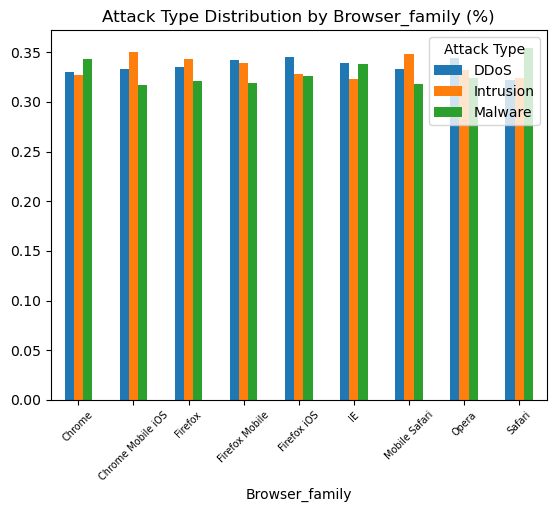

In [58]:
# Check attack type distribution per Browser_family => pretty fair distributed
# Margin to see row and columns total
# Conclusion: we can keep Browser_family (to test) cause despite imbalance of each values of Browser_family, but
# the attack type (target) are fairly distributed, but need to stratify while splitting train/test
ct = pd.crosstab(df['Browser_family'], df['Attack Type'], margins=True)
print(ct)

# 2. Visualize to spot imbalances (% of each attack type)
pd.crosstab(df['Browser_family'], df['Attack Type'], normalize='index').plot(kind='bar')
plt.title("Attack Type Distribution by Browser_family (%)")
plt.xticks(rotation=45, fontsize=7)
plt.show()

In [59]:
# Analyse for OS_family - need to DECIDE !!! Check distribution of attack type below !!
# OS_family => 5 distinct values, Windows occupies 45% with smallest Android occupies 8%
# Should we keep this as is or drop, data too imbalance ?
# Or put Windows then others?
count = df['OS_family'].value_counts()
pct = (df['OS_family'].value_counts(normalize=True) * 100).round(2)

OS_family_summary = pd.DataFrame({
    'Count': count,
    'Percentage': pct
})

OS_family_summary

,Count,Percentage
OS_family,,
Windows,17953,44.88
Linux,7171,17.93
Mac OS X,5813,14.53
iOS,5774,14.44
Android,3289,8.22


Attack Type   DDoS  Intrusion  Malware    All
OS_family                                    
Android       1112       1086     1091   3289
Linux         2464       2371     2336   7171
Mac OS X      1894       1920     1999   5813
Windows       6014       5906     6033  17953
iOS           1944       1982     1848   5774
All          13428      13265    13307  40000


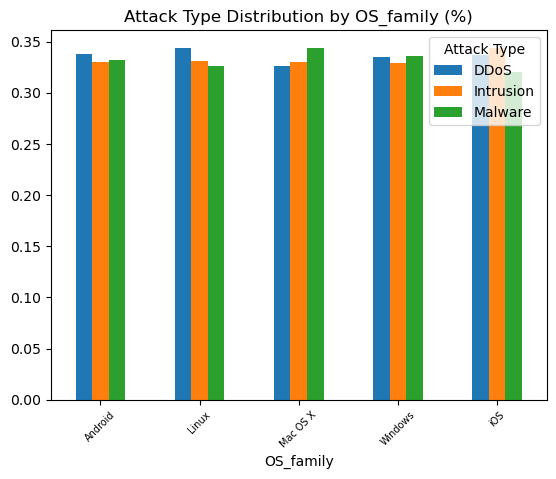

In [60]:
# Check attack type distribution per OS_family => pretty fair distributed
# Margin to see row and columns total
# Conclusion: we can keep OS_family (to test) cause despite imbalance of each values of OS_family, but
# the attack type (target) are fairly distributed, but need to stratify while splitting train/test
ct = pd.crosstab(df['OS_family'], df['Attack Type'], margins=True)
print(ct)

# 2. Visualize to spot imbalances (% of each attack type)
pd.crosstab(df['OS_family'], df['Attack Type'], normalize='index').plot(kind='bar')
plt.title("Attack Type Distribution by OS_family (%)")
plt.xticks(rotation=45, fontsize=7)
plt.show()

In [61]:
# Analyse for Device_family - need to DECIDE !!! Check plot below
# Device_family => 8 distinct values, Others occupies 59% with smallest LG UG occupies 0.16%
# Should we keep this as is or drop, data imbalance ? 
count = df['Device_family'].value_counts()
pct = (df['Device_family'].value_counts(normalize=True) * 100).round(2)

Device_family_summary = pd.DataFrame({
    'Count': count,
    'Percentage': pct
})

Device_family_summary

,Count,Percentage
Device_family,,
Other,23678,59.20
Mac,5796,14.49
Generic Smartphone,4211,10.53
iPod,2656,6.64
iPhone,1567,3.92
iPad,1551,3.88
Generic Tablet,475,1.19
LG UG,66,0.16


Attack Type          DDoS  Intrusion  Malware    All
Device_family                                       
Generic Smartphone   1426       1369     1416   4211
Generic Tablet        164        178      133    475
LG UG                  27         21       18     66
Mac                  1887       1915     1994   5796
Other                7980       7800     7898  23678
iPad                  534        521      496   1551
iPhone                524        537      506   1567
iPod                  886        924      846   2656
All                 13428      13265    13307  40000


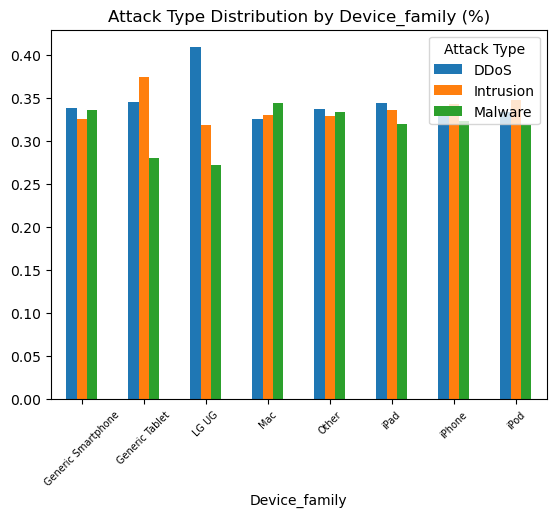

In [62]:
# Need to DECIDE
# Check attack type distribution per Device_family => pretty fair distributed except
# for Generic Tablet and LG UG where they have certain attack type at around 40% (issue of too few samples and imbalance of attack types as target)
# Margin to see row and columns total
# Conclusion: Either drop this column entirely or create top X and group others
ct = pd.crosstab(df['Device_family'], df['Attack Type'], margins=True)
print(ct)

# 2. Visualize to spot imbalances (% of each attack type)
pd.crosstab(df['Device_family'], df['Attack Type'], normalize='index').plot(kind='bar')
plt.title("Attack Type Distribution by Device_family (%)")
plt.xticks(rotation=45, fontsize=7)
plt.show()

In [63]:
# Create new feature of Device_type using ua_agents library - to analyze
from user_agents import parse as ua_parse

def deviceType(ua_string):
    try:
        if not ua_string or pd.isna(ua_string):
            return pd.NA
        ua = ua_parse(ua_string)           # user_agents.parse -> object with is_mobile/is_tablet/is_pc
        if getattr(ua, "is_mobile", False):
            return "Mobile"
        if getattr(ua, "is_tablet", False):
            return "Tablet"
        if getattr(ua, "is_pc", False):
            return "PC"
        return "Unknown"
    except Exception:
        return "Unknown"

# apply
df['Device_type'] = df['Device Information'].apply(deviceType)
# deviceType("Mozilla/5.0 (iPhone; CPU iPhone OS 5_1_1 like Mac OS X) AppleWebKit/533.0 (KHTML, like Gecko) CriOS/51.0.844.0 Mobile/22B509 Safari/533.0")

In [64]:
# Check distribution of each device_type
# Attention: Unknown and Tablet - only 7% and 2.5% respectively
df['Device_type'].value_counts(normalize=True)

Device_type
PC         0.669050
Mobile     0.236775
Unknown    0.069450
Tablet     0.024725
Name: proportion, dtype: float64

Attack Type   DDoS  Intrusion  Malware    All
Device_type                                  
Mobile        3191       3195     3085   9471
PC            8948       8839     8975  26762
Tablet         343        334      312    989
Unknown        946        897      935   2778
All          13428      13265    13307  40000


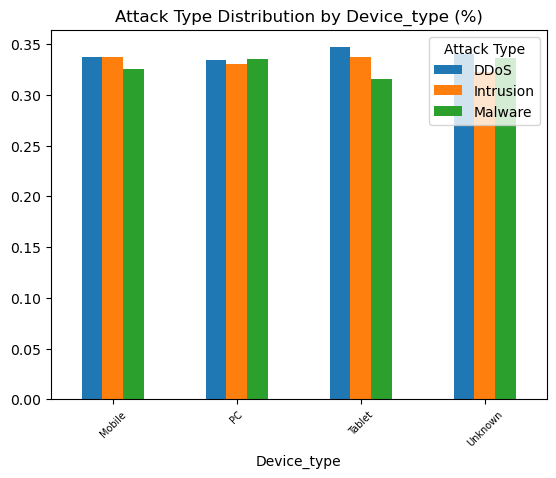

In [65]:
# Check distribution of attack type to Device_type - well distributed, even for Unknown and Tablet (which has less data)
# Conclusion: Need to DECIDE !!! Maybe choose between either use Device_family or Device_type?
# If have to choose, Device_type might be better cause the data is less imbalance than Device_family which has 59% pr Others,
# also iPad and iPhone are both from Apple, and Generic smartphone could be Samsung or Pixel which don't have same systems etc ?
# hence Device_family can cause more overfitting for Others and it is too sparse (extreme outlier of LG UG at only 0.16%)
ct = pd.crosstab(df['Device_type'], df['Attack Type'], margins=True)
print(ct)

# 2. Visualize to spot imbalances (% of each attack type)
pd.crosstab(df['Device_type'], df['Attack Type'], normalize='index').plot(kind='bar')
plt.title("Attack Type Distribution by Device_type (%)")
plt.xticks(rotation=45, fontsize=7)
plt.show()

In [66]:
# Detect if any bots from Device Family
# Conclusion: no bot detected
is_bot_series = df['Device Information'].apply(lambda x: ua_parse(x).is_bot)
is_bot_series.value_counts()

Device Information
False    40000
Name: count, dtype: int64

In [ ]:
# Drop Device Information - no longer needed
df = df.drop(columns=['Device Information'])

In [68]:
# Recheck for any missing values for new features created
df.isna().sum()

Protocol                     0
Packet Type                  0
Traffic Type                 0
Malware Indicators           0
Alerts/Warnings              0
Attack Type                  0
Attack Signature             0
Action Taken                 0
Severity Level               0
Network Segment              0
Geo-location Data            0
Firewall Logs                0
IDS/IPS Alerts               0
Log Source                   0
is_weekend                   0
hours_div                    0
ContinentName_Source         0
ContinentName_Destination    0
ContinentName_Proxy          0
Source IP_Class              0
Destination IP_Class         0
Proxy_Class                  0
Source Port_Cat              0
Destination Port_Cat         0
Packet Length_Bin            0
Packet Length_Quartile       0
Anomaly Scores_Quartile      0
Browser_family               0
OS_family                    0
Device_family                0
Device_type                  0
dtype: int64

### Feature Engineering and analysis for Geo-location Data

In [74]:
# this column contains 2 data, separated by comma, maybe it's like city and province?
df["GeoLoc_City1"] = df["Geo-location Data"].apply(lambda x: x.split(",")[0].strip())
df["GeoLoc_City2"] = df["Geo-location Data"].apply(lambda x: x.split(",")[-1].strip())

In [ ]:
df["GeoLoc_City1"].nunique(), df["GeoLoc_City2"].nunique()
# (316, 28)
# High cardinality

(316, 28)

In [79]:
# Since User Information seems like all Indian users, and Geo-Location Data seems all in India, maybe we can check the country based on cities we extracted for further analysis
# Extract country from GeoLoc_City1 using geopy
from geopy.geocoders import Nominatim
from geopy.exc import GeocoderTimedOut, GeocoderServiceError
import time

geolocator = Nominatim(user_agent="city_to_country", timeout=3)

def get_country_from_city(city_name):
    if not city_name or pd.isna(city_name):
        return 'not identified'
    try:
        location = geolocator.geocode(city_name, timeout=3)
        if location:
            return location.address.split(',')[-1].strip()  # Extract country
        return 'not identified'
    except (GeocoderTimedOut, GeocoderServiceError):
        return 'not identified'
    except Exception:
        return 'not identified'

# OPTIMIZED: Only geocode unique city names to avoid redundant API calls (cause too slow)
unique_cities = df['GeoLoc_City1'].dropna().unique()
print(f"Found {len(unique_cities)} unique cities to geocode")

# Create a mapping dictionary
city_to_country = {}
for i, city in enumerate(unique_cities):
    if i % 10 == 0:  # Progress update every 10 cities
        print(f"Processing {i}/{len(unique_cities)}...")
    city_to_country[city] = get_country_from_city(city)
    time.sleep(1.1)  # Respect Nominatim rate limit (1 request per second)

# Map the results to the dataframe
df['GeoLoc_Country1'] = df['GeoLoc_City1'].map(city_to_country).fillna('not identified')
print(f"\nCompleted! Sample result: {get_country_from_city('Noida')}")

Found 316 unique cities to geocode
Processing 0/316...
Processing 10/316...
Processing 20/316...
Processing 30/316...
Processing 40/316...
Processing 50/316...
Processing 60/316...
Processing 70/316...
Processing 80/316...
Processing 90/316...
Processing 100/316...
Processing 110/316...
Processing 120/316...
Processing 130/316...
Processing 140/316...
Processing 150/316...
Processing 160/316...
Processing 170/316...
Processing 180/316...
Processing 190/316...
Processing 200/316...
Processing 210/316...
Processing 220/316...
Processing 230/316...
Processing 240/316...
Processing 250/316...
Processing 260/316...
Processing 270/316...
Processing 280/316...
Processing 290/316...
Processing 300/316...
Processing 310/316...

Completed! Sample result: India


In [80]:
# Extract country from GeoLoc_City2 using geopy
geolocator = Nominatim(user_agent="city_to_country", timeout=3)

def get_country_from_city(city_name):
    if not city_name or pd.isna(city_name):
        return 'not identified'
    try:
        location = geolocator.geocode(city_name, timeout=3)
        if location:
            return location.address.split(',')[-1].strip()  # Extract country
        return 'not identified'
    except (GeocoderTimedOut, GeocoderServiceError):
        return 'not identified'
    except Exception:
        return 'not identified'

# OPTIMIZED: Only geocode unique city names to avoid redundant API calls
unique_cities = df['GeoLoc_City2'].dropna().unique()
print(f"Found {len(unique_cities)} unique cities to geocode")

# Create a mapping dictionary
city_to_country = {}
for i, city in enumerate(unique_cities):
    if i % 10 == 0:  # Progress update every 10 cities
        print(f"Processing {i}/{len(unique_cities)}...")
    city_to_country[city] = get_country_from_city(city)
    time.sleep(1.1)  # Respect Nominatim rate limit (1 request per second)

# Map the results to the dataframe
df['GeoLoc_Country2'] = df['GeoLoc_City2'].map(city_to_country).fillna('not identified')
print(f"\nCompleted! Sample result: {get_country_from_city('Orai')}")

Found 28 unique cities to geocode
Processing 0/28...
Processing 10/28...
Processing 20/28...

Completed! Sample result: España


In [ ]:
# Check which countries
# GeoLoc_Country2 => all India
# GeoLoc_Country1 => 38k India, rest US, Italia, Romania, Espana, not identified (after checked, some cities in different countries might have same name)
# Conclusion: can assume all in India, coherent with all Indian User Information name
df["GeoLoc_Country1"].value_counts(), df["GeoLoc_Country2"].value_counts()

(GeoLoc_Country1
 India             38765
 not identified      587
 United States       273
 Italia              134
 România             123
 España              118
 Name: count, dtype: int64,
 GeoLoc_Country2
 India    40000
 Name: count, dtype: int64)

In [ ]:
# Drop GeoLoc_City1 and GeoLoc_City2 - high cardinality and no longer needed
df = df.drop(columns=['GeoLoc_City1', 'GeoLoc_City2'])

In [ ]:
# Drop GeoLoc_Country1 and GeoLoc_Country2 - won't help the model, even if we want to check if Source and Destination IP from India (too less data)
df = df.drop(columns=['GeoLoc_Country1', 'GeoLoc_Country2'])

In [ ]:
# Drop Geo-location Data - not useful in modeling
df = df.drop(columns=['Geo-location Data'])

In [89]:
df.columns

Index(['Protocol', 'Packet Type', 'Traffic Type', 'Malware Indicators',
       'Alerts/Warnings', 'Attack Type', 'Attack Signature', 'Action Taken',
       'Severity Level', 'Network Segment', 'Geo-location Data',
       'Firewall Logs', 'IDS/IPS Alerts', 'Log Source', 'is_weekend',
       'hours_div', 'ContinentName_Source', 'ContinentName_Destination',
       'ContinentName_Proxy', 'Source IP_Class', 'Destination IP_Class',
       'Proxy_Class', 'Source Port_Cat', 'Destination Port_Cat',
       'Packet Length_Bin', 'Packet Length_Quartile',
       'Anomaly Scores_Quartile', 'Browser_family', 'OS_family',
       'Device_family', 'Device_type'],
      dtype='object')

In [ ]:
# Save the processed df after first FE&DA. It contains:
# # Index(['Protocol', 'Packet Type', 'Traffic Type', 'Malware Indicators',
#        'Alerts/Warnings', 'Attack Type', 'Attack Signature', 'Action Taken',
#        'Severity Level', 'Network Segment', 'Geo-location Data',
#        'Firewall Logs', 'IDS/IPS Alerts', 'Log Source', 'is_weekend',
#        'hours_div', 'ContinentName_Source', 'ContinentName_Destination',
#        'ContinentName_Proxy', 'Source IP_Class', 'Destination IP_Class',
#        'Proxy_Class', 'Source Port_Cat', 'Destination Port_Cat',
#        'Packet Length_Bin', 'Packet Length_Quartile',
#        'Anomaly Scores_Quartile', 'Browser_family', 'OS_family',
#        'Device_family', 'Device_type'],
#       dtype='object')
import os
# Create processed_data directory if it doesn't exist
os.makedirs('../data/processed_data', exist_ok=True)

# Save as CSV
df.to_csv('../data/processed_data/cybersecurity_attacks_firstFE&EDA.csv', index=False)
print("DataFrame saved as CSV!")

DataFrame saved as CSV!


In [92]:
# doesn't show spike of Blocked if Severity Level is High
df.groupby(['Attack Type', 'Severity Level'])['Action Taken'].value_counts()

Attack Type  Severity Level  Action Taken
DDoS         High            Ignored         1549
                             Blocked         1508
                             Logged          1466
             Low             Blocked         1509
                             Ignored         1500
                             Logged          1441
             Medium          Logged          1529
                             Blocked         1516
                             Ignored         1410
Intrusion    High            Blocked         1523
                             Logged          1469
                             Ignored         1435
             Low             Blocked         1506
                             Ignored         1451
                             Logged          1417
             Medium          Blocked         1524
                             Ignored         1515
                             Logged          1425
Malware      High            Blocked         1499
        

ATTACK TYPE DISTRIBUTION BY SEVERITY LEVEL & ACTION TAKEN


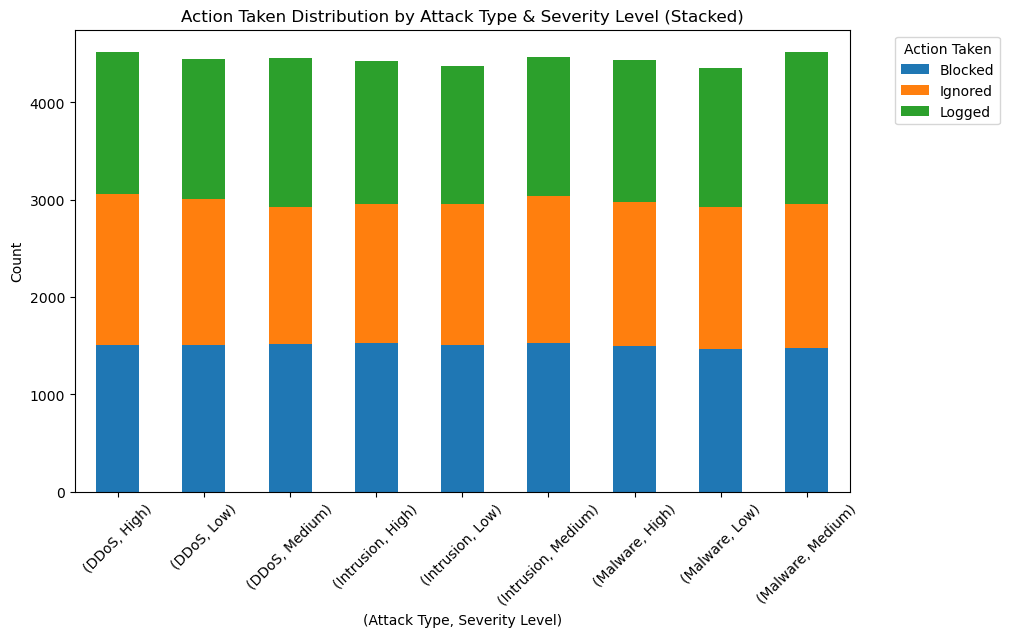

In [93]:
# ===== ANALYZE ATTACK TYPE BY SEVERITY LEVEL & ACTION TAKEN =====
print("=" * 80)
print("ATTACK TYPE DISTRIBUTION BY SEVERITY LEVEL & ACTION TAKEN")
print("=" * 80)

# Step 1: Get the grouped data
grouped_data = df.groupby(['Attack Type', 'Severity Level'])['Action Taken'].value_counts().reset_index(name='Count')
# print("\nDetailed Breakdown:")
# print(grouped_data)

# Step 2: Create multiple visualizations
fig, ax = plt.subplots(figsize=(10, 6))

# Plot 1: Stacked bar chart - Attack Type by Severity Level (colored by Action Taken)
pivot_data = grouped_data.pivot_table(
    index=['Attack Type', 'Severity Level'], 
    columns='Action Taken', 
    values='Count', 
    fill_value=0
)
pivot_data.plot(kind='bar', ax=ax, stacked=True)
ax.set_title("Action Taken Distribution by Attack Type & Severity Level (Stacked)")
ax.set_xlabel("(Attack Type, Severity Level)")
ax.set_ylabel("Count")
ax.legend(title='Action Taken', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.tick_params(axis='x', rotation=45)